Experiment 1: Working with Python packages-Numpy, Scipy, Scikit-Learn,
Matplotlib

**Iris Dataset**

In [258]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Iris.csv")
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [259]:
print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [260]:

print("\ninfo:")
print(df.info())
print("shape:", df.shape)
print("\nSpecies counts:")
print(df["Species"].value_counts())


info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
shape: (150, 6)

Species counts:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [261]:
df.drop(columns=['Id'], inplace=True)
df.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [262]:
#Descriptive statistics
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
df[features].describe()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Exploratory Data Analysis (EDA)

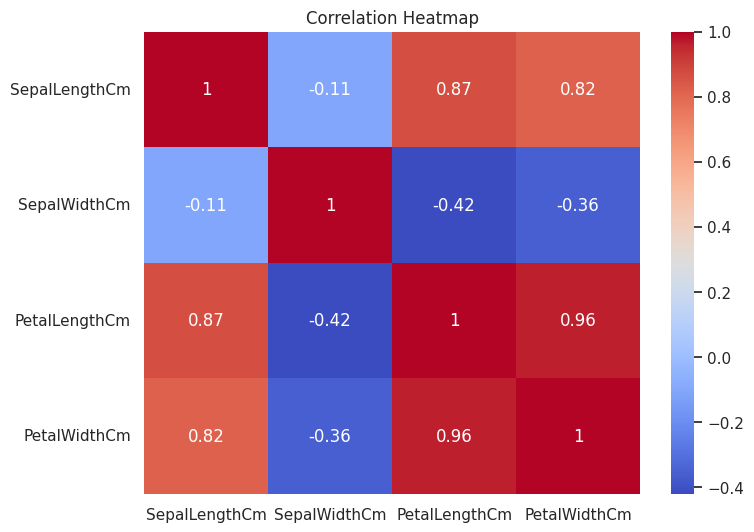

In [263]:
# 1. Select only numeric columns as shown in the cheat sheet
num_colmn = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Generate heatmap using only those numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(df[num_colmn].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

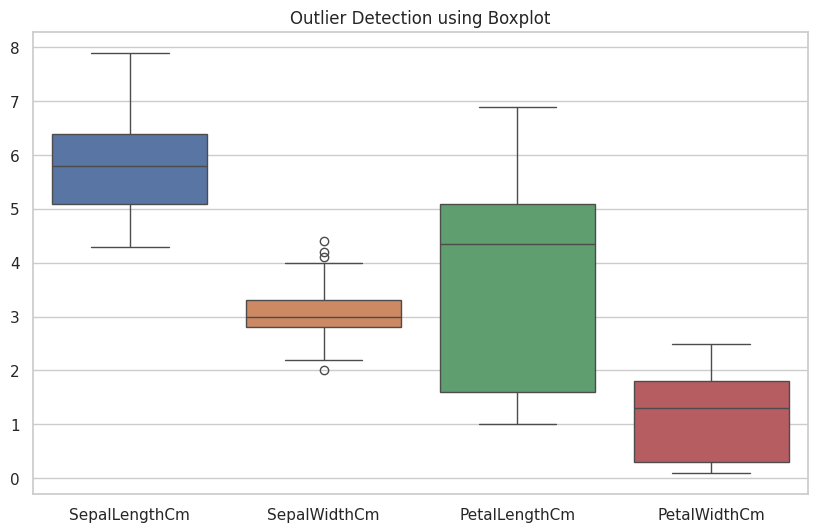

In [264]:
# Box Plot for outlier detection
plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop(columns=['Species']))
plt.title("Outlier Detection using Boxplot")
plt.show()

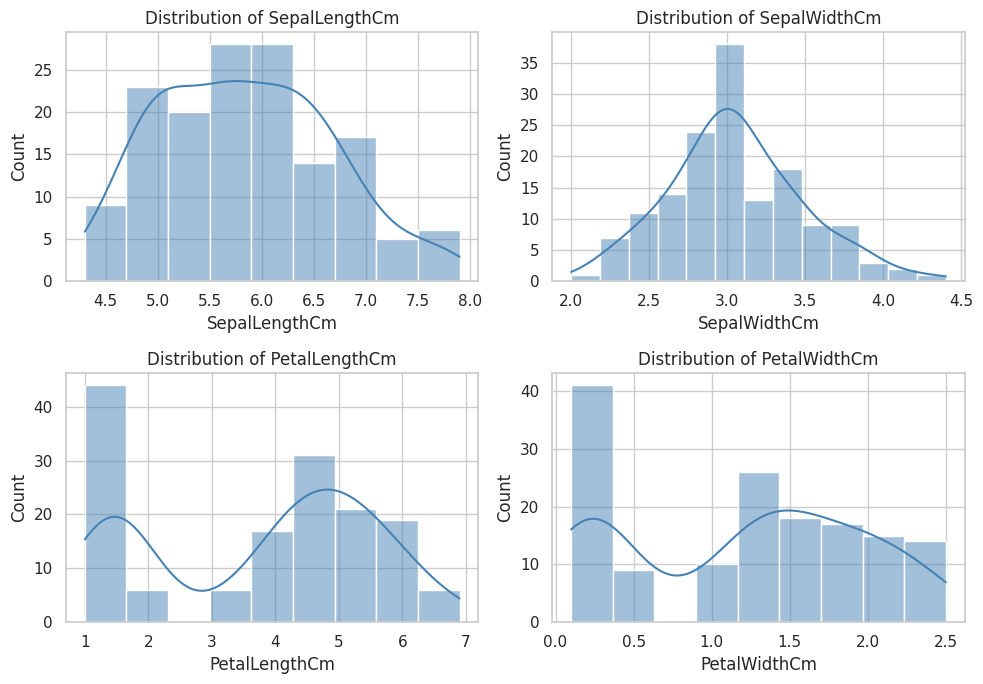

In [265]:
# Create subplots for histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), features):
    # Using kde=True as per your EDA document requirements for distribution analysis
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

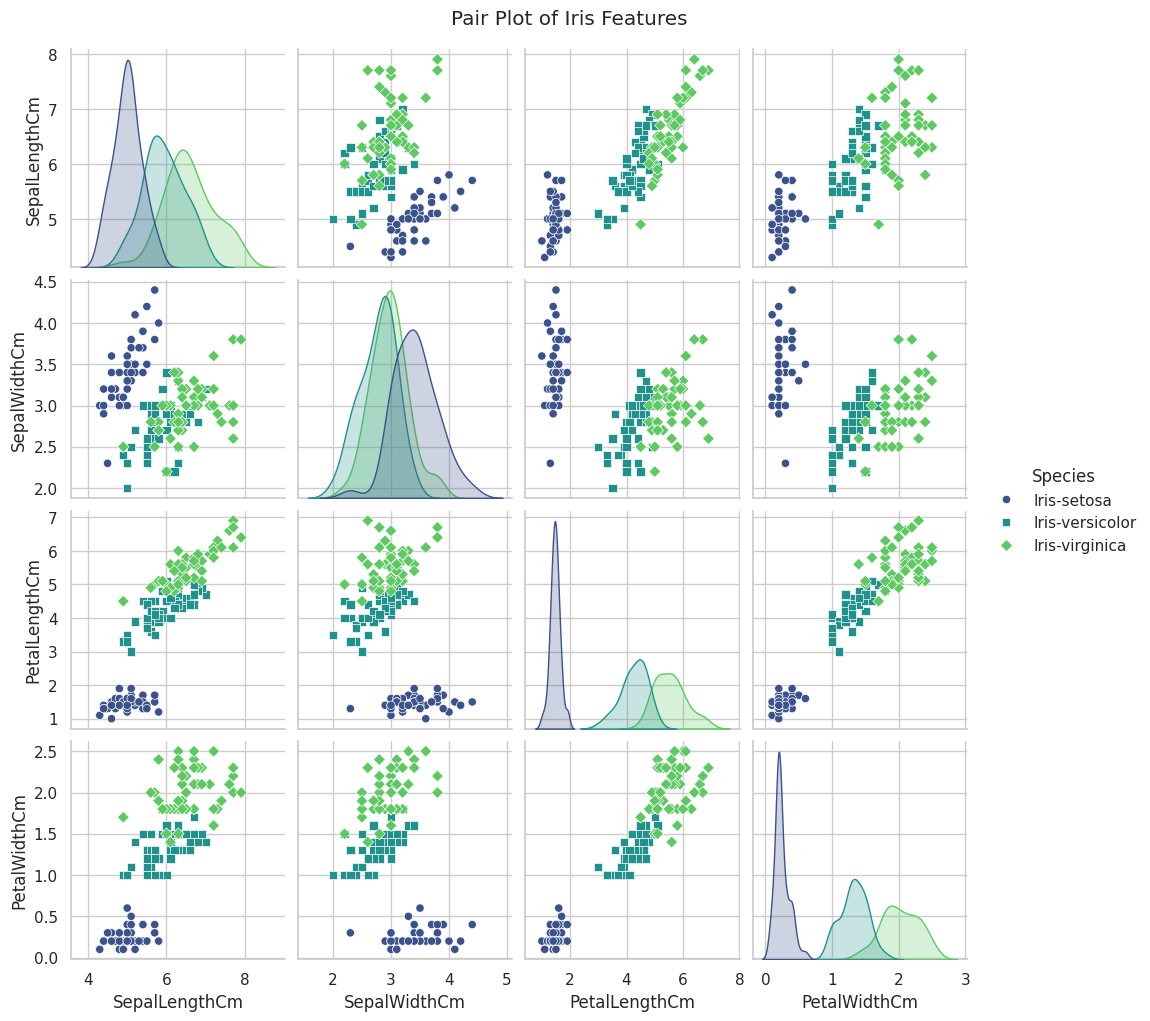

In [266]:
#pair plot
sns.pairplot(df, hue='Species', palette='viridis', markers=["o", "s", "D"])
plt.suptitle("Pair Plot of Iris Features", y=1.02)
plt.show()

**Diabetes Dataset**

In [267]:
df = pd.read_csv("diabetes.csv")
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [268]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [269]:
print(df.info())
print(df.describe())
print("shape:", df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

Exploratory Data Analysis (EDA)

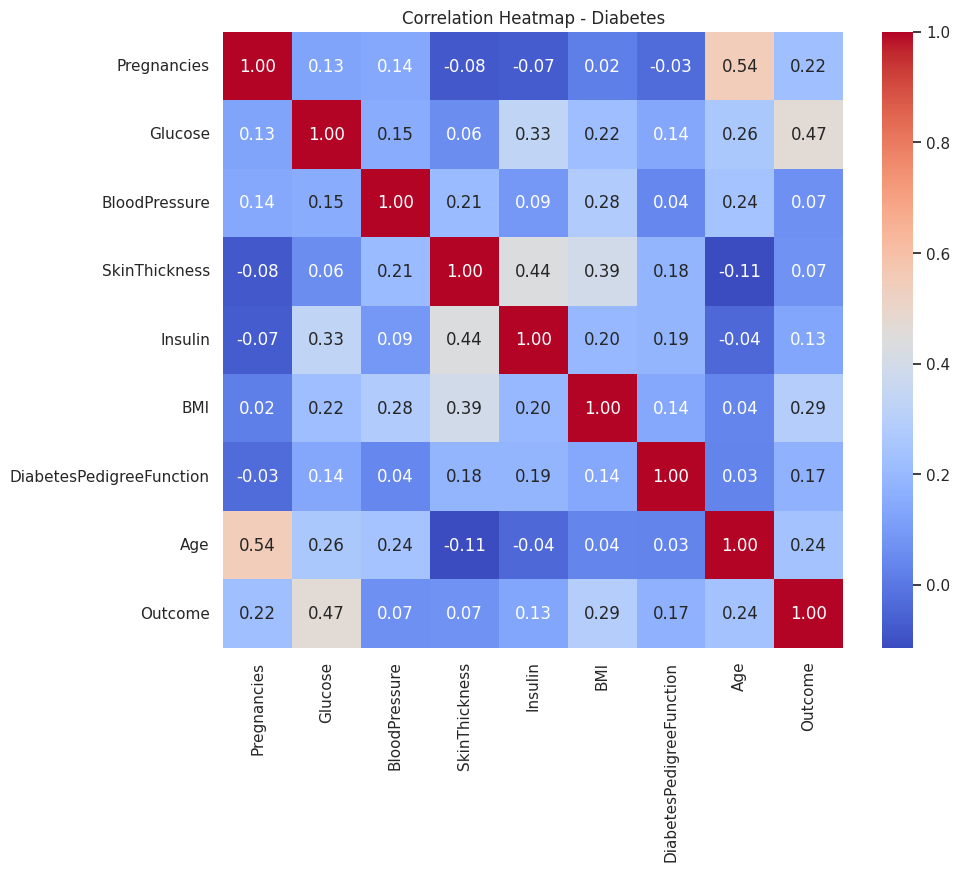

In [270]:
#Correlation Heatmap
num_colmn = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_colmn].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap - Diabetes")
plt.show()

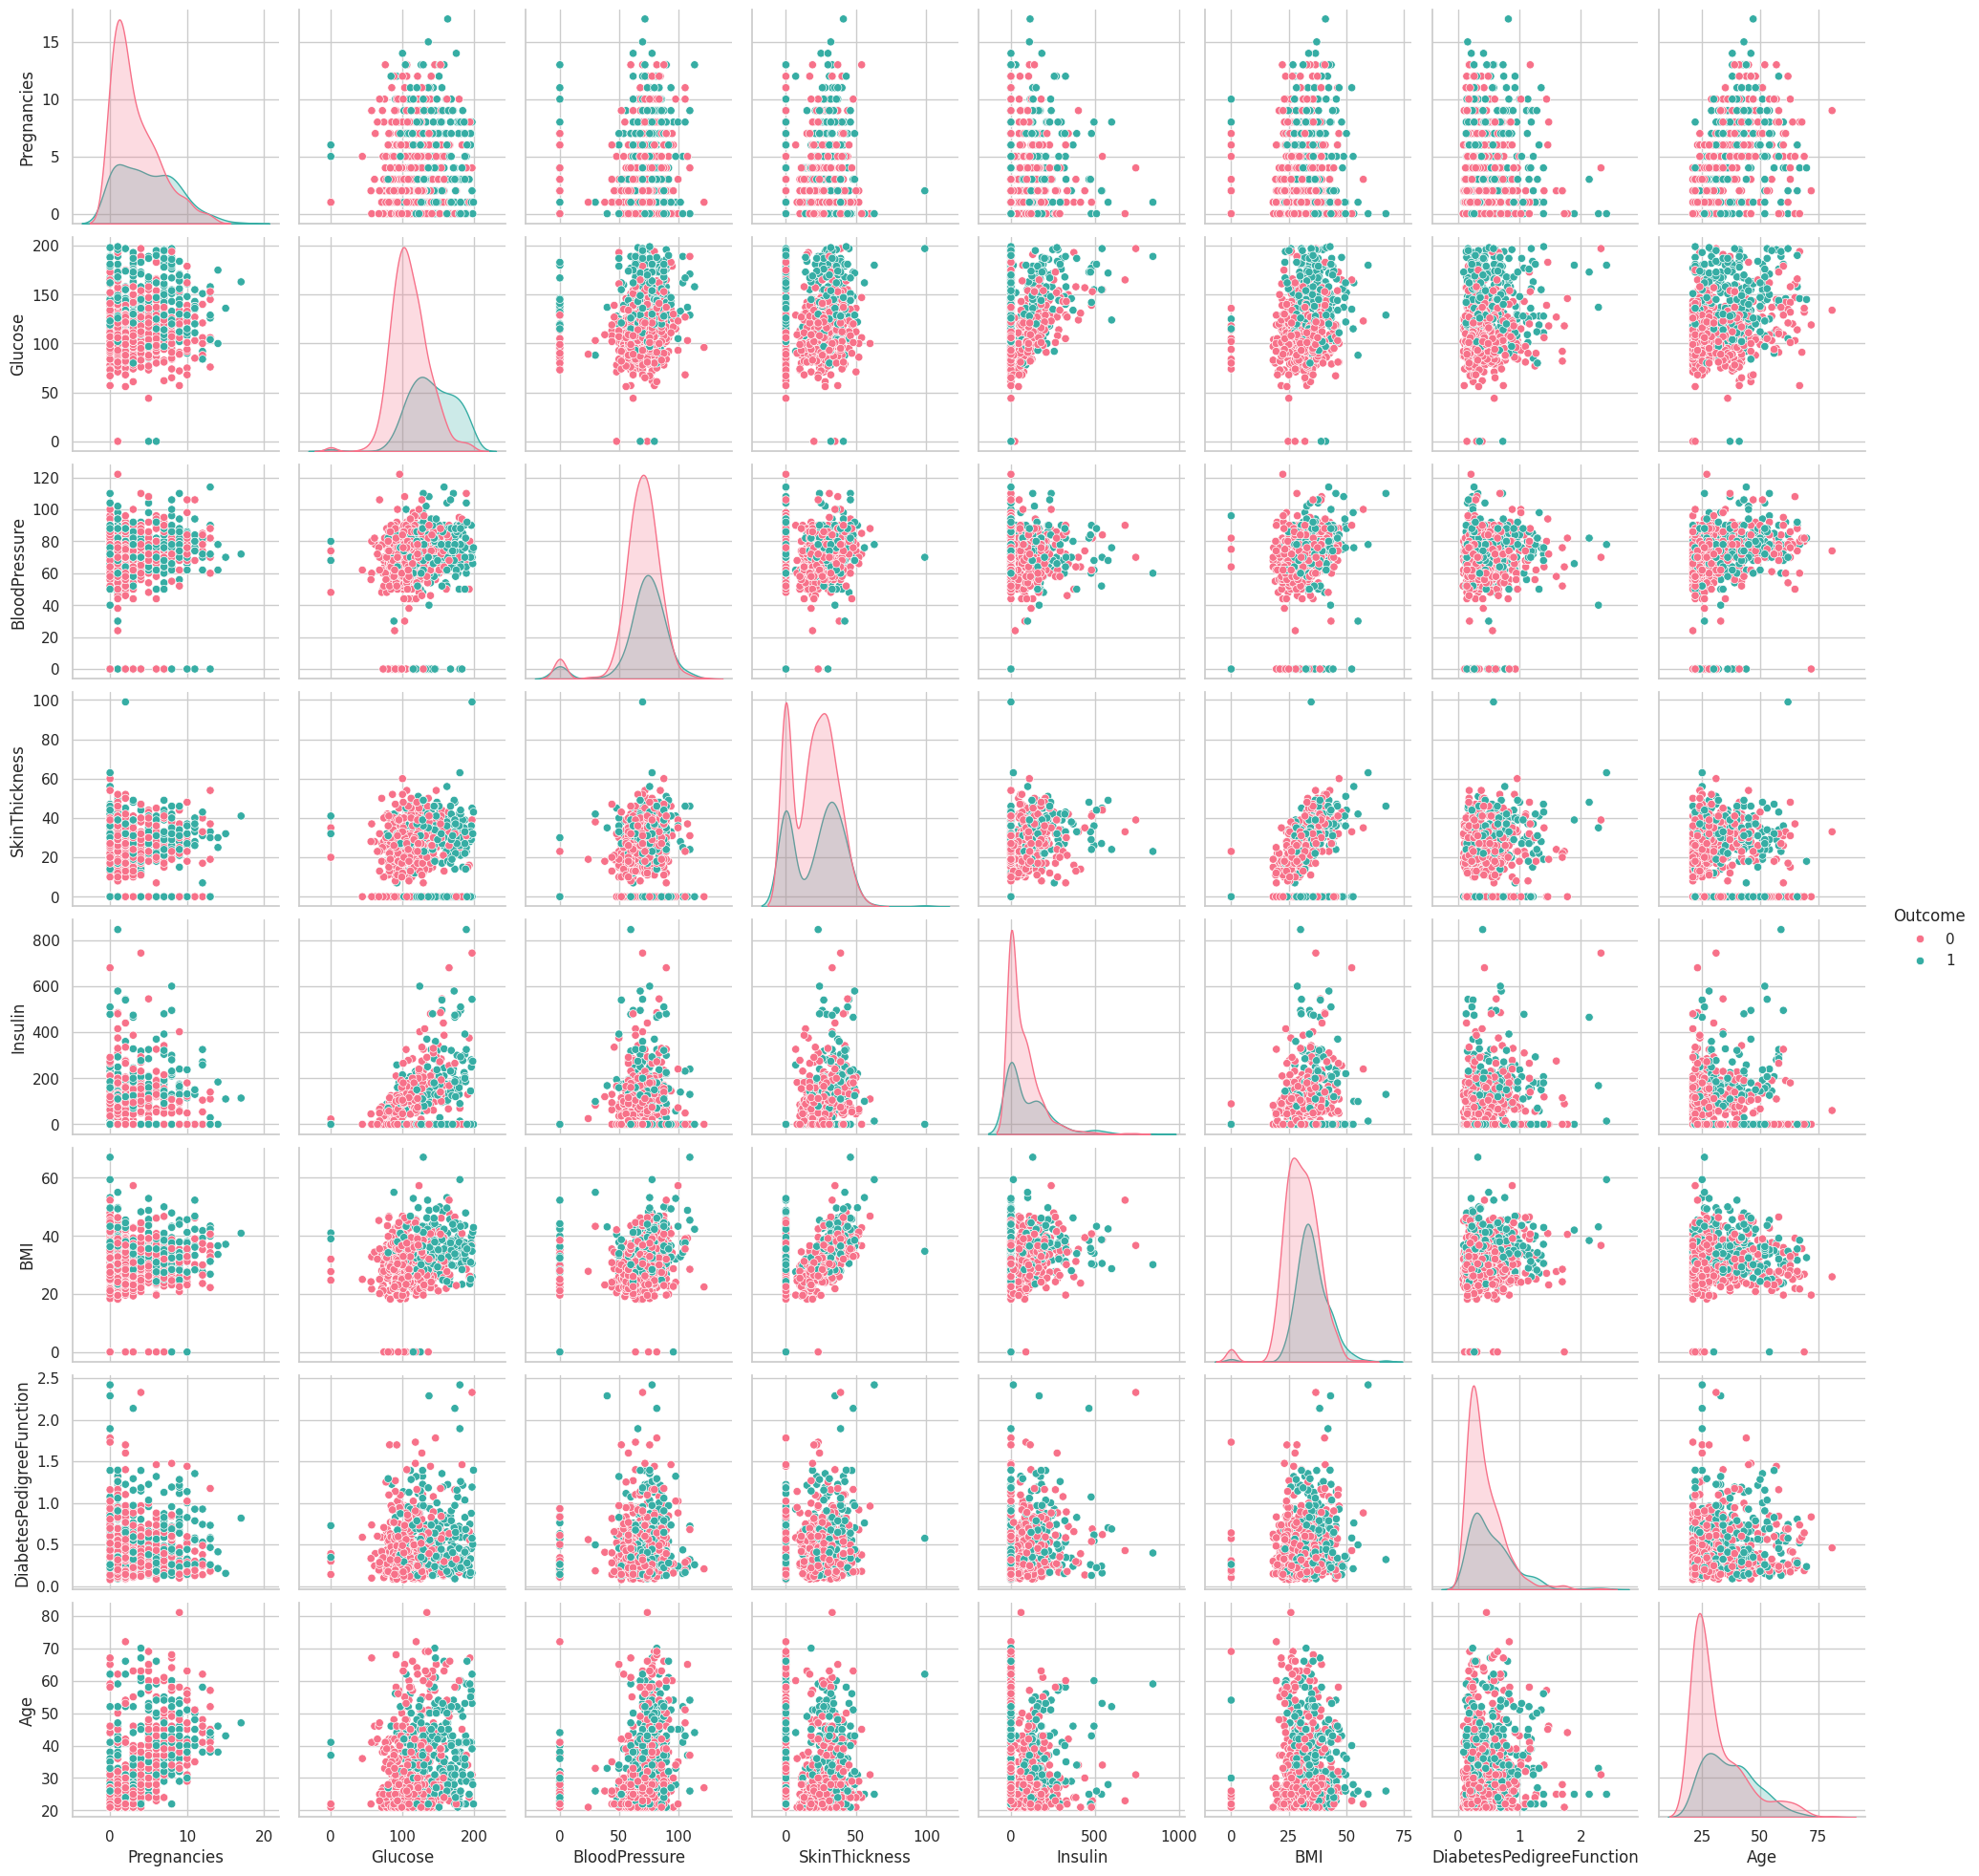

In [271]:
#Pair Plot
sns.pairplot(df, hue='Outcome', palette='husl')
plt.show()

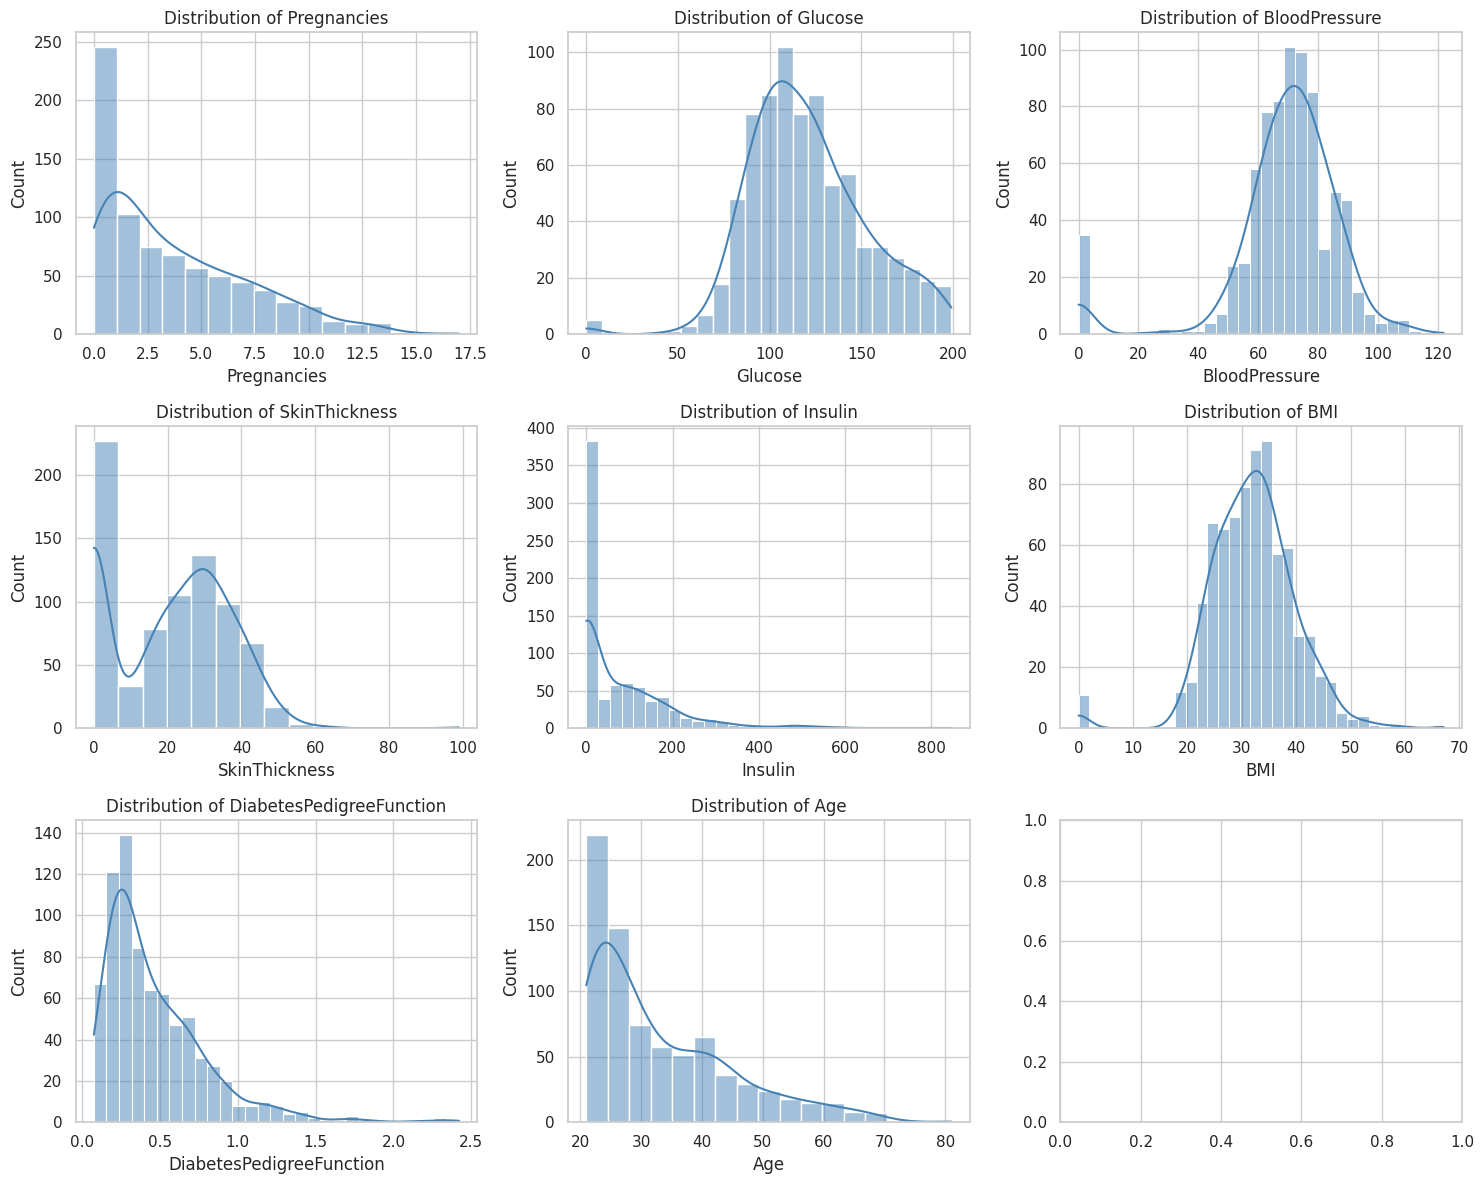

In [272]:
# 4. Histograms (Dynamic feature selection)
features = df.columns[:-1] # This automatically gets Diabetes columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

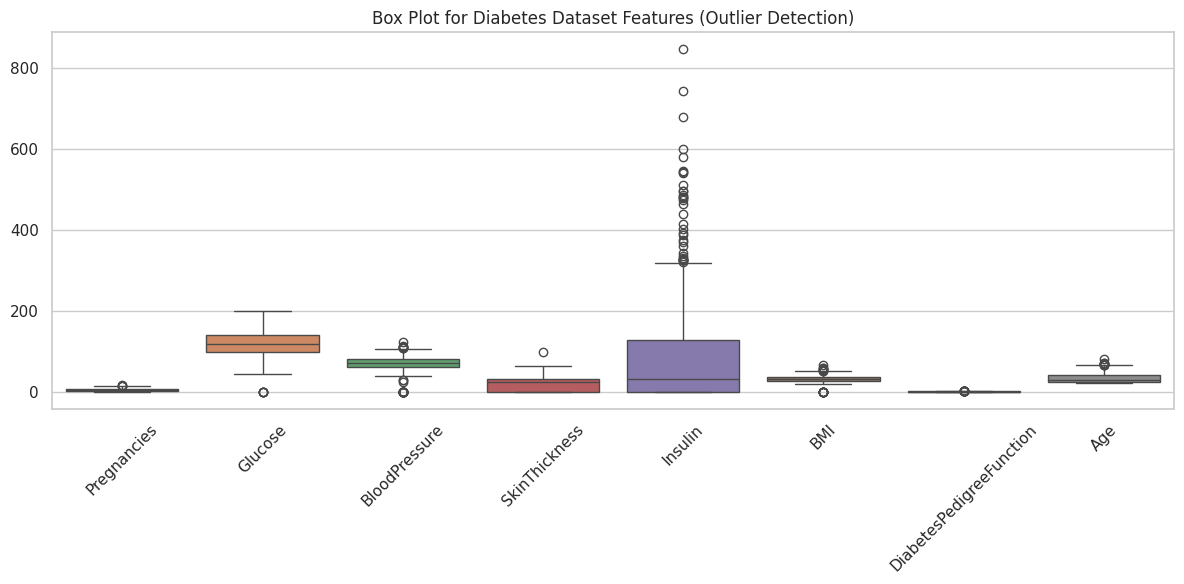

In [273]:
# Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_colmn].drop(columns=['Outcome']))
plt.xticks(rotation=45)
plt.title("Box Plot for Diabetes Dataset Features (Outlier Detection)")
plt.tight_layout()
plt.show()

**Loan approval prediction Dataset**

In [274]:
df = pd.read_csv("loan.csv")
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [275]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


In [276]:
print(df.info())
print(df.describe())
print("shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       367.000000         367.000000  362.000000        361.000000   
mean 

In [277]:
df.drop(columns=['Loan_ID'], inplace=True)

# Handle Missing Values
df.dropna(inplace=True)
df.head(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
4,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban


Exploratory Data Analysis (EDA)

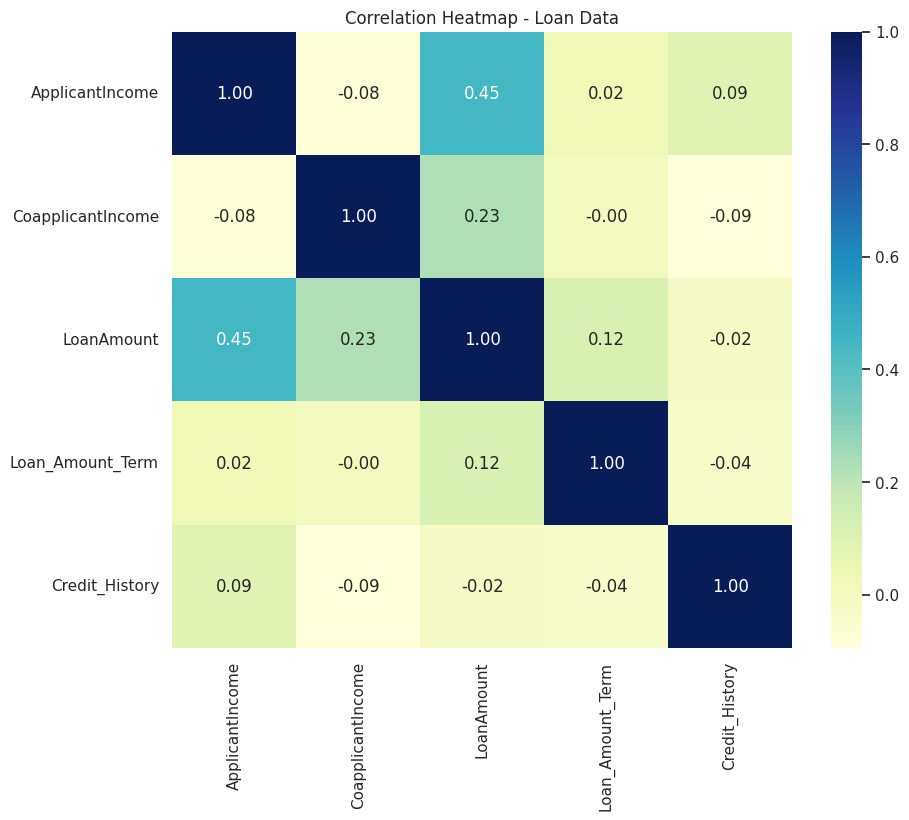

In [278]:
# Correlation Heatmap
num_colmn = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_colmn].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlation Heatmap - Loan Data")
plt.show()

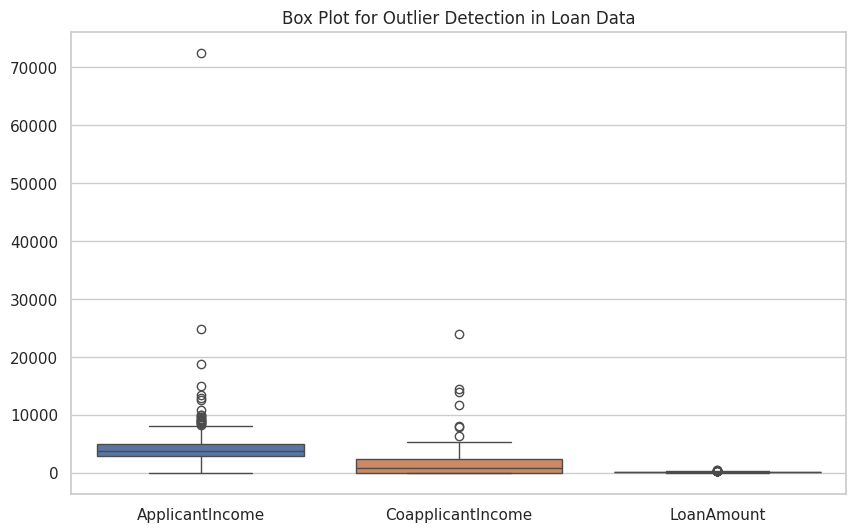

In [279]:
#Box Plot (Outlier Detection)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']])
plt.title("Box Plot for Outlier Detection in Loan Data")
plt.show()

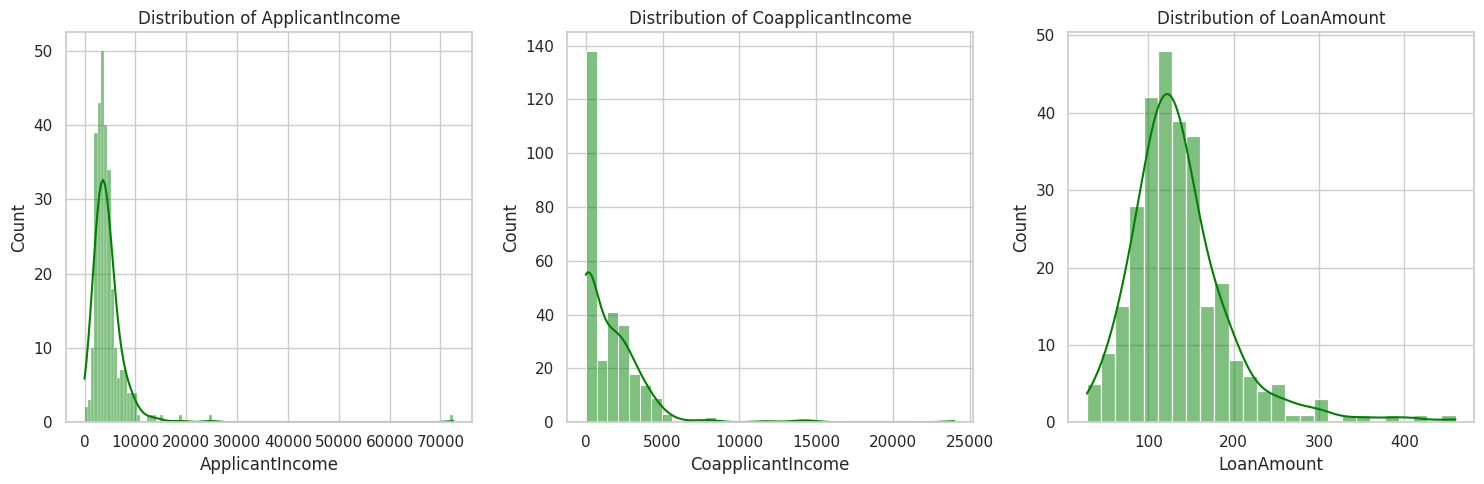

In [280]:
# Histograms
features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="green")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

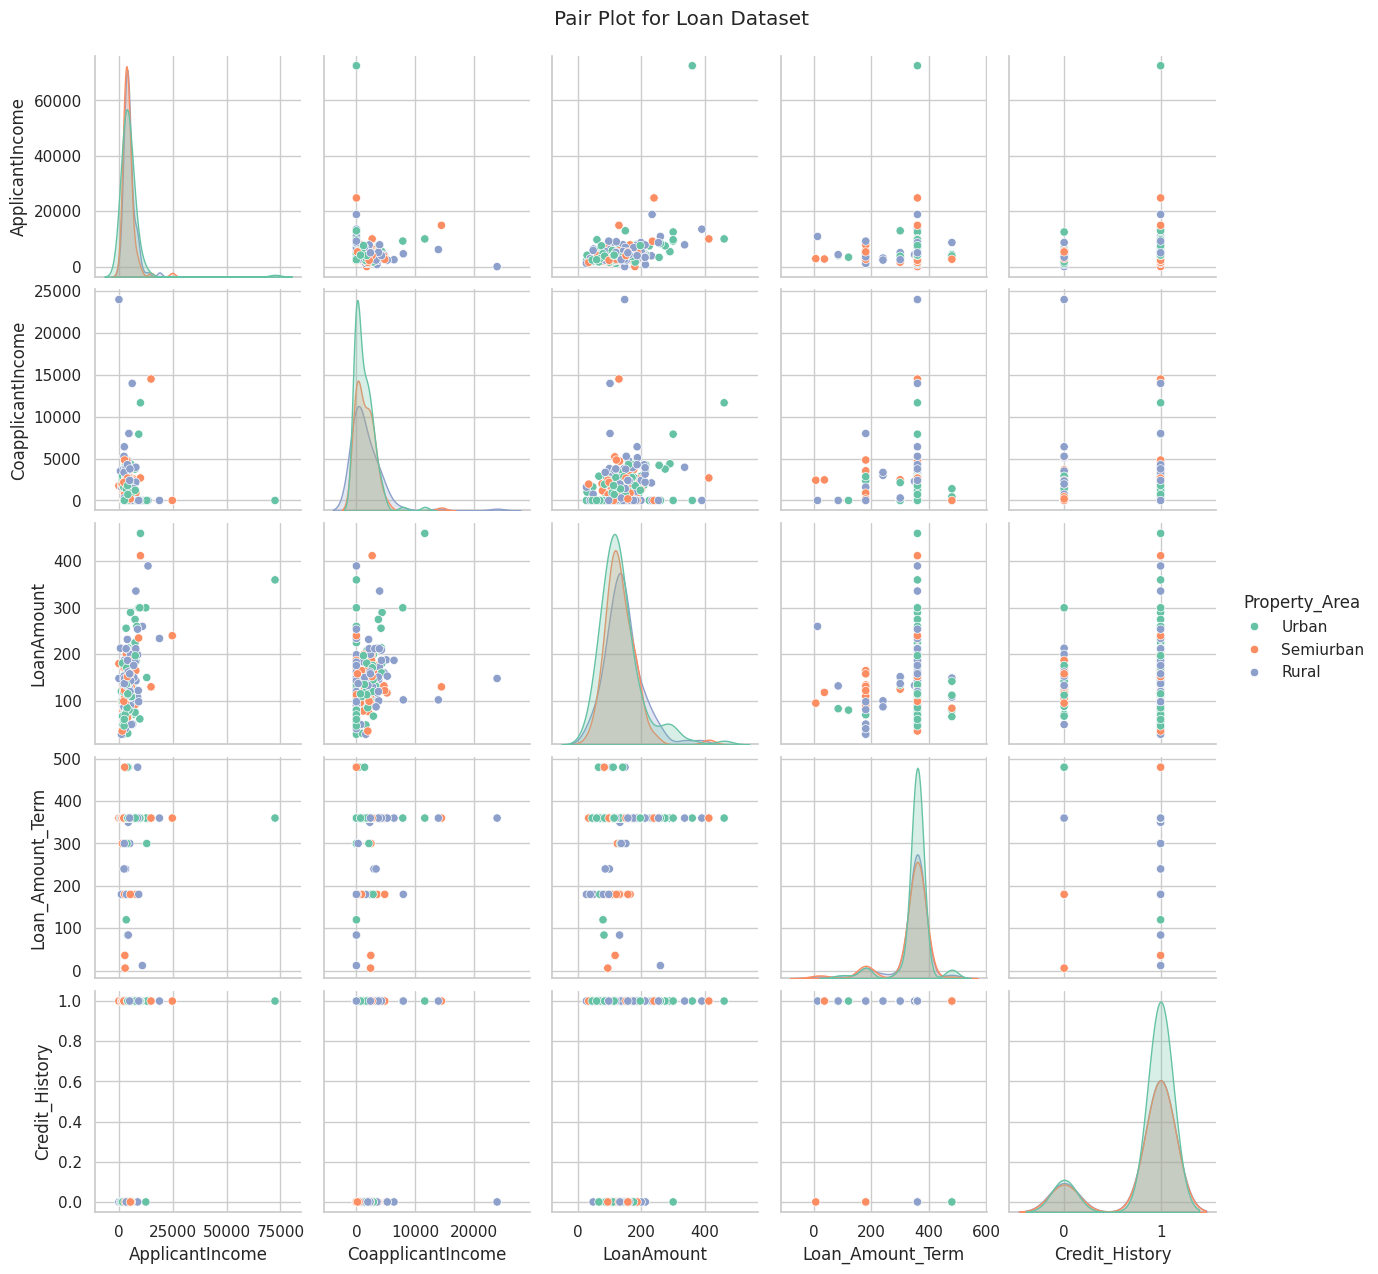

In [281]:
#pairplot
sns.pairplot(df, hue='Property_Area', palette='Set2', diag_kind='kde')
plt.suptitle("Pair Plot for Loan Dataset", y=1.02)
plt.show()

**Handwritten character recognition**

In [282]:
import cv2
import os
import math

In [283]:
df = pd.read_csv("/content/drive/MyDrive/handwritten/english.csv")
df.head(5)

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [284]:
print(df.columns)
print(df.info())
print(df.describe())
print("shape:", df.shape)

Index(['image', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB
None
                     image label
count                 3410  3410
unique                3410    62
top     Img/img062-055.png     0
freq                     1    55
shape: (3410, 2)


Exploratory Data Analysis (EDA)

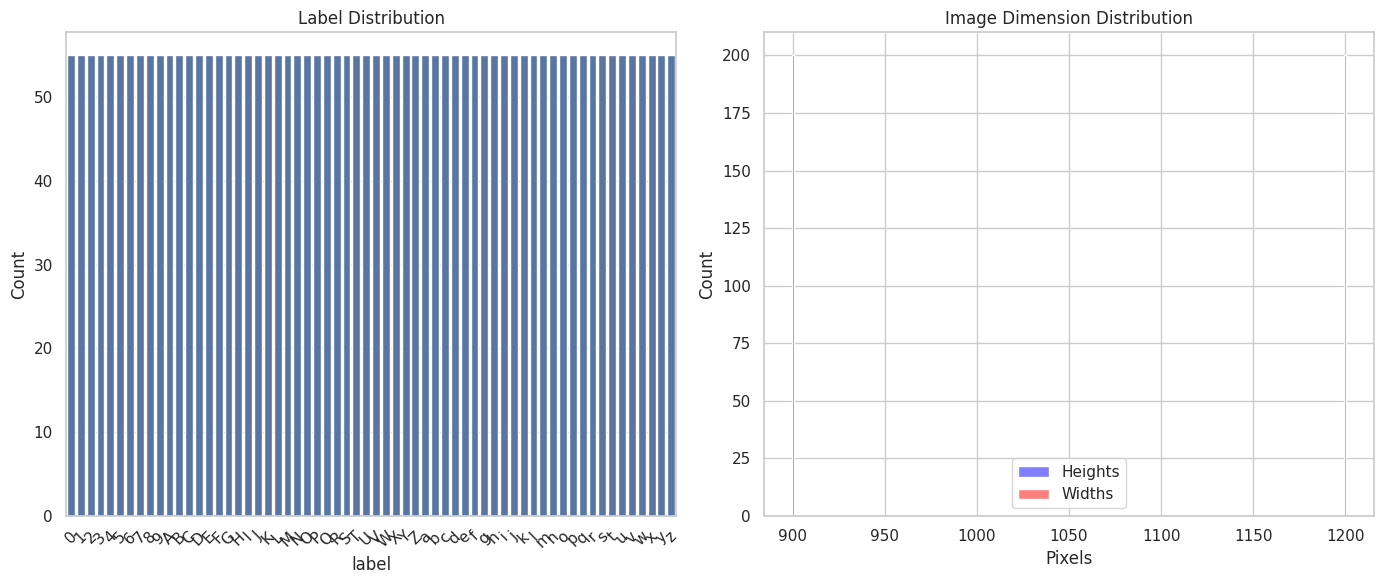

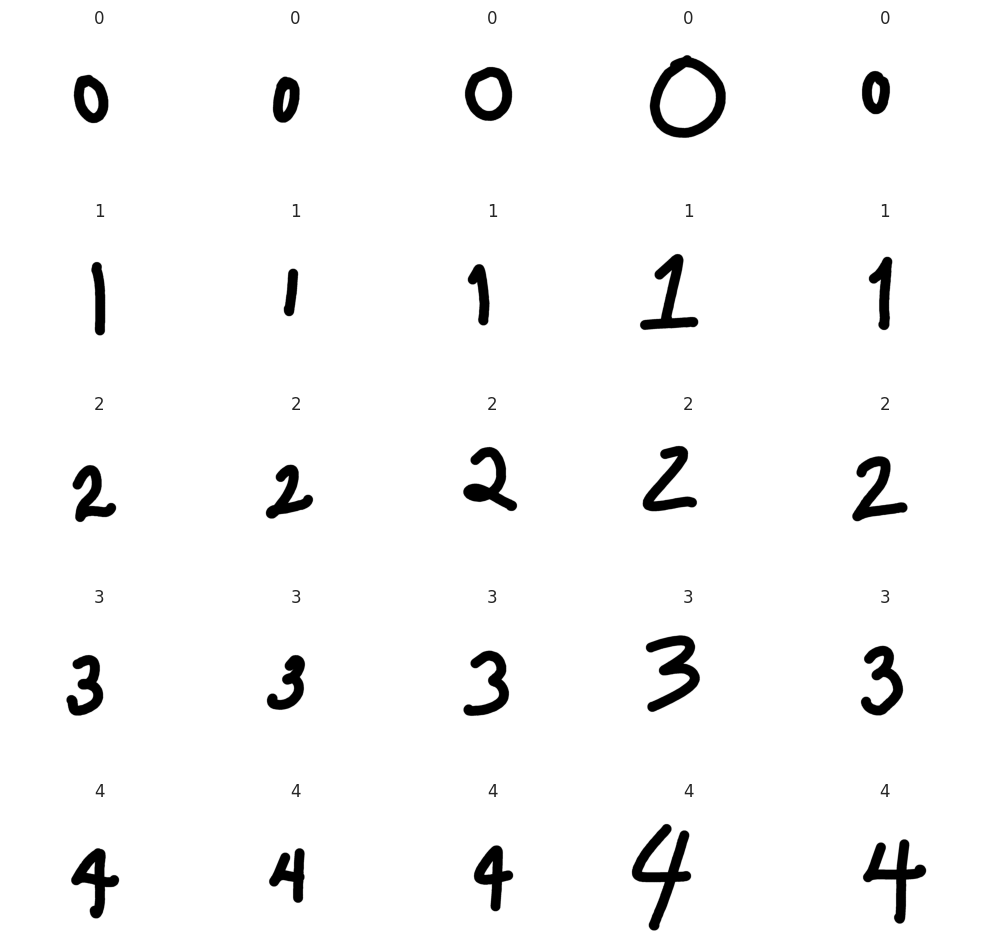

In [285]:

# ============================
# 3. Label distribution and image-dimension overview (1x2 grid)
# ============================
heights, widths = [], []
for img_path in df["image"].sample(min(200, len(df)), random_state=42):
    if os.path.exists("/content/drive/MyDrive/handwritten/"+img_path):
        img = cv2.imread("/content/drive/MyDrive/handwritten/"+img_path)
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# label distribution on left
sns.countplot(data=df, x="label", order=df["label"].value_counts().index, ax=axes[0])
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# image dimension distributions on right
sns.histplot(heights, kde=True, color="blue", label="Heights", ax=axes[1], linewidth=1)
sns.histplot(widths, kde=True, color="red", label="Widths", ax=axes[1], linewidth=1)
axes[1].legend()
axes[1].set_title("Image Dimension Distribution")
axes[1].set_xlabel("Pixels")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig('handwritten_overview.ebs', format='png')
plt.show()

# ============================
# 4. Preview sample images
# ============================
def show_samples(df, labels, samples_per_label=5):
    fig, axes = plt.subplots(len(labels), samples_per_label,
                             figsize=(samples_per_label*2, len(labels)*2))
    for i, label in enumerate(labels):
        subset = df[df["label"] == label].sample(samples_per_label, random_state=42)
        for j, img_path in enumerate(subset["image"].values):
            if os.path.exists("/content/drive/MyDrive/handwritten/"+img_path):
                img = cv2.imread("/content/drive/MyDrive/handwritten/"+img_path, cv2.IMREAD_GRAYSCALE)
                axes[i, j].imshow(img, cmap="gray")
                axes[i, j].axis("off")
                axes[i, j].set_title(str(label))
            else:
                axes[i, j].text(0.5, 0.5, "Missing", ha="center", va="center")
                axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

# Example: show samples for first 5 labels
unique_labels = df["label"].unique()
show_samples(df, unique_labels[:5], samples_per_label=5)

**Email Spam Dataset**

In [286]:
df = pd.read_csv("spam.csv")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [287]:
print(df.columns)

Index(['Category', 'Message'], dtype='object')


In [288]:
print(df.info())
print(df.describe())
print("shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
       Category                 Message
count      5572                    5572
unique        2                    5157
top         ham  Sorry, I'll call later
freq       4825                      30
shape: (5572, 2)


In [289]:
df['Length'] = df['Message'].apply(len)

print(df.head())

  Category                                            Message  Length
0      ham  Go until jurong point, crazy.. Available only ...     111
1      ham                      Ok lar... Joking wif u oni...      29
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...     155
3      ham  U dun say so early hor... U c already then say...      49
4      ham  Nah I don't think he goes to usf, he lives aro...      61


Exploratory Data Analysis (EDA)

/tmp/ipython-input-665107219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


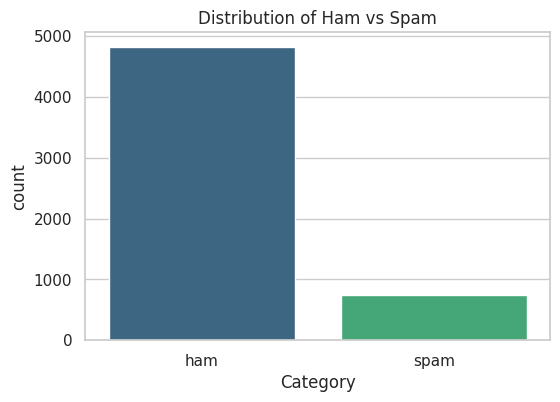

In [290]:
#Count Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Category', palette='viridis')
plt.title("Distribution of Ham vs Spam")
plt.show()

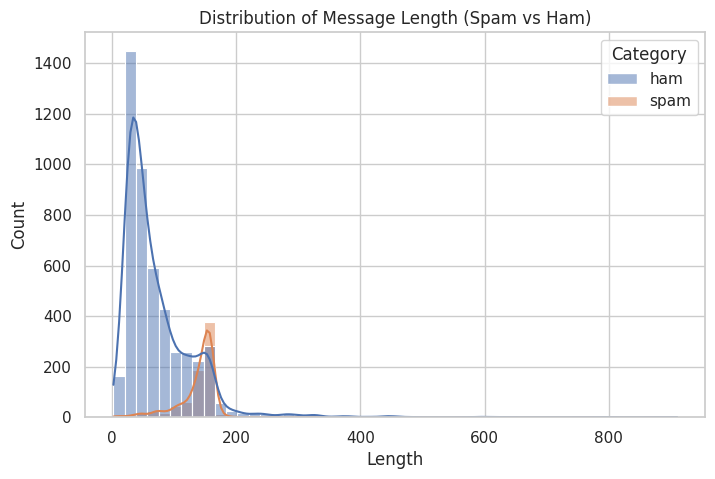

In [291]:
# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Length', hue='Category', kde=True, bins=50)
plt.title("Distribution of Message Length (Spam vs Ham)")
plt.show()

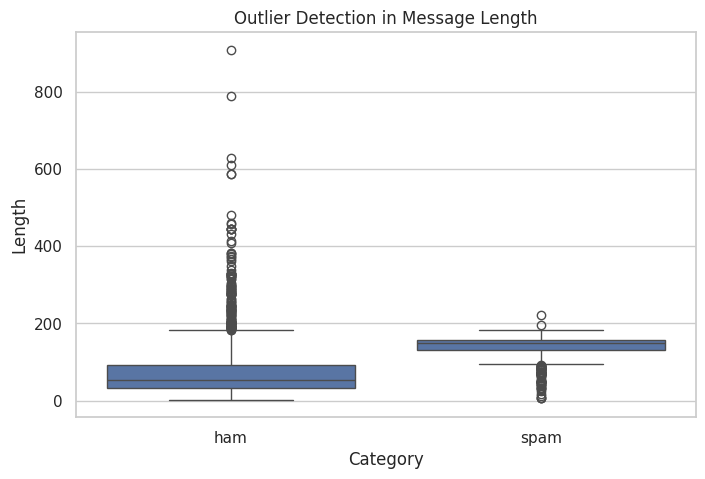

In [292]:
# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Category', y='Length')
plt.title("Outlier Detection in Message Length")
plt.show()

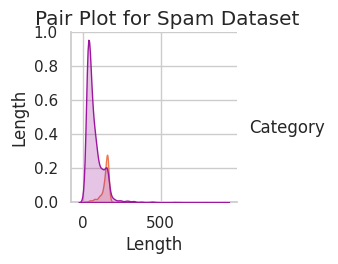

In [293]:
# Pair Plot
sns.pairplot(df, hue='Category', palette='plasma', diag_kind='kde')
plt.suptitle("Pair Plot for Spam Dataset", y=1.02)
plt.show()